In [1]:
#| output: false

import numpy as np
from math import log
from Scripts import severe_malaria
from Scripts import paper
from Scripts import goncalves
from model import Parameters

default_pars = Parameters()
p = goncalves.get_estimates('../Data_Fitting/Goncalves/goncalves1_draws.csv')

# Introduction

Severe malaria episode data from @goncalves_parasite_2014 demonstrates that the risk of a clinical episode becoming severe decays exponentially with number of infections:

$$\text{Pr(clinical episode becomes severe on $n^\text{th}$infection)} = \rho_\text{severe}e^{-\delta_\text{severe}[n-1]}$$

where $\rho_\text{severe}$ is the risk of a clinical episode becoming severe on first infection and $\delta_\text{severe}$ is the decay in the risk with number of infections. 

Estimates of the decay rate and the risk on first infection have been obtained by @munoz_sandoval_plasmodium_2025, and by ourselves ([Notebook S4](S4_goncalves.ipynb)). We estimated $\rho_\text{severe}$ to be `{python} f'{p.P_severe.mean():.1%}'` $\pm$ `{python} f'{p.P_severe.std():.1%}'` and $\delta_\text{severe}$ to be `{python} f'{p.dS.mean():.2f}'` $\pm$ `{python} f'{p.dS.std():.2f}'`  — which corresponds to a halving of risk every `{python} f'{log(2)/p.dS.mean():.1f}'` infections.

# Consequences of this model for severe malaria and mortality age patterns

In @fig-initial_consequences we plot severe malaria and mortality age patterns for 1 and 5 blood infections per year using the simple model described above.

At 5 infections per year (red lines) severe malaria episode rate and mortality rate drop rapidly in the first few years of life resulting in roughly 25% of children having at least one severe episode and about 1.7% of children dying.

At 1 infection per year (purple lines) the severe episode rate and the mortality rate remain high into the early teens and there is a second peak in deaths due to rising death rate with age after 4 years old (@reyburn_association_2005; [Notebook S7](S7_death_rate.ipynb)). Cumulative severe episodes rise more slowly and plateau at the same level as for 5 infections per year. Cumulative deaths also rise more slowly but reach higher levels than 5 infections per year, again due to the rising death rate with age.

So, although this simple model of exposure-only reduction in risk of severe malaria fits data from @goncalves_parasite_2014, it is not entirely consistent with other mortality age-pattern datasets as we show below.

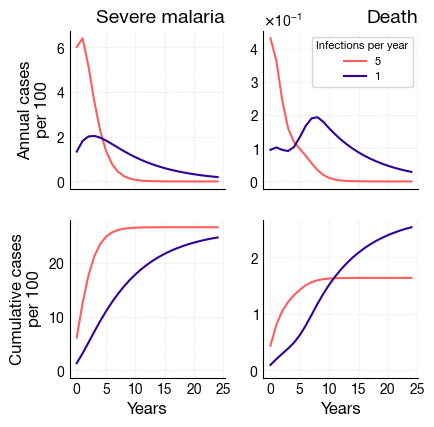

In [2]:
#| label: fig-initial_consequences
#| fig-cap: "Severe malaria and mortality rates and cunulative episodes for 1 and 5 infections per child per year assuming exposure-only dependent reduction in risk of severe malaria."

fig, axs = paper.unvaccinated(λs=(5, 1), popsize=100, ε_severe=0, years=26, fig_xscale=0.75, fig_yscale=0.75, vars=[]);

# Evidence in support of a more complex model of severe malaria immunity

@abdullah_patterns_2007 published mortality age patterns based on verbal autopsies in seven sites with different transmission intensities. The open circles in @fig-abdullah-fig1 show malaria-specific deaths per 1,000 person years at risk from 0-2 years of age (left-hand panels) and 2-14 years of age (right-hand panels). Kisumu and Manhiça have the lowest transmission intensities (actual rates were not given in @abdullah_patterns_2007). There is no indication of a substantial or prolonged second peak in any site and most deaths occur within the first four years of life.  

:::{#fig-abdullah-fig1}
![](Figures/abdulla_2007_fig1.png){height=75%}

Age-specific mortality rates from @abdullah_patterns_2007. Left panels: 0-2 year olds; right panels 2-14 year olds. Closed squares: all cause mortality; open circles: malaria-specific mortality. Permission to reproduce pending.
:::

Cumulative probabilities of malaria-specific deaths by age for each site are shown in  @fig-abdullah-fig2a. There are two features in this data not captured by our model. First, cumulative probabilities plateau at different levels for the different transmission intensities: Manhiça showing the lower cumulative probability. Second, the shoulder in the curves occurs at around three years of age irrespective of transmission intensity.

:::{#fig-abdullah-fig2a}
![](Figures/abdulla_2007_fig2b.png)

Cumulative probability of malaria specific mortality by given age. Figures in parenthesis are the overall probability of dying by age 15 years. For Kisumu the data analysed refer only to ages 0–5 years, and the figures in parenthesis are the probability of dying by age 5 years. Permission to reproduce pending.
:::

@reyburn_association_2005 recorded 1989 severe malaria episodes from hospital admissions from northeastern Tanzania in villages experiencing different transmission intensities, stratified as low, medium and high. Denominator data is not available so severe malaria rates cannot be calculated. However, cumulative age patterns are plotted in @fig-reyburn_data. As for deaths, the shoulders in the curves occur in the under fives; a pattern not reproduced by our model.

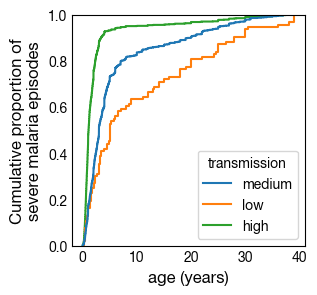

In [4]:
#| label: fig-reyburn_data
#| fig-cap: "Cumulative age patterns of severe malaria from @reyburn_association_2005."

fig, ax = severe_malaria.reyburn_data()

# A modified model with risk reducing with age-dependent exposure

A simple addition to make our model consistent with the observed severe malaria and death age patterns is to allow the rate of decay of risk of severe malaria to also be dependent on age. A possible modified model is 

$$\text{Pr(clinical episode becomes severe on $n^\text{th}$ infection at age $a$)} = \rho_\text{severe}e^{-[\delta_\text{severe} + \epsilon_\text{severe}a][n-1]}$$

where the new parameter $\epsilon_\text{severe}$ introduces age dependent reduction in risk with exposure.

[@fig-epsilon_severe] demonstrates the effect $\epsilon_\text{severe}$ has on severe malaria and death age patterns when $\lambda=1$ infection per year. In particular it suppresses the second peak in deaths in the five to ten year olds. It also reduces the cumulative number of severe malaria episodes and deaths. Although we have no data to formally fit $\epsilon_\text{severe}$, based on the verbal autopsy data in @abdullah_patterns_2007, a value of `{python} default_pars.ε_severe` per infection per year seems reasonable. 


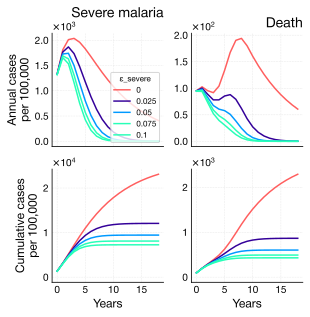

In [4]:
#| label: fig-epsilon_severe
#| fig-cap: One infection per year.

fig, axs = severe_malaria.ε_severe_calibration(fig_xscale=0.75, fig_yscale=0.75, legend_pos='first', legend_title='ε_severe')


Setting $\epsilon_\text{severe} =$ `{python} default_pars.ε_severe` per infection per year, and using our estimated values of $\rho_\text{severe}=$ `{python} f'{p.P_severe.mean():.3f}'` and $\delta_\text{severe}=$ `{python} f'{p.dS.mean():.2f}'` per infection, we get risk curves as shown in @fig-severe_malaria_risk. Irrespective of age, the risk of a clinical episode on first infection becoming severe is 4.2%. However, older children with the same number of infections as younger children are less at risk of severe malaria.

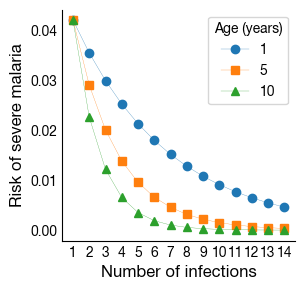

In [6]:
#| label: fig-severe_malaria_risk
#| fig-cap: "Risk of a clinical episode becoming severe depends on age and exposure."

fig, ax = severe_malaria.severe_malaria_risk_plot()


For this modified model, the consequences for age patterns are shown in @fig-consequences. Now, compared to 5 infections per year, 1 infection per year:

1. does not exhibit a second peak in deaths
2. has lower cumulative severe malaria episodes and deaths 
3. a similar age when cumulative severe malaria episodes and deaths plateau

There are, of course, several caveats with this model. First, we have no immunological evidence that risk decays with age. Second, we have no high quality epidemiological data across sites with different transmission intensities with which to estimate $\epsilon_\text{severe}$.

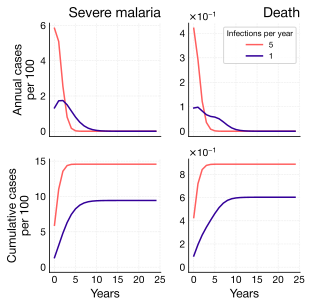

In [6]:
#| label: fig-consequences
#| fig-cap: "Severe malaria and mortality rates and cunulative episodes for 1 and 5 infections per child per year assuming age-dependent exposure reduction in risk of severe malaria."

fig, axs = paper.unvaccinated(λs=(5, 1), popsize=100, years=26, fig_xscale=0.75, fig_yscale=0.75, vars=[]);

# Validation of severe malaria age patterns

Typical age patterns of severe malaria are shown in @fig-okiro-fig2. 

:::{#fig-okiro-fig2}
![](Figures/okiro_2009_fig2.png)

Age distribution of hospitalized malaria from 17 communities arranged by decreasing *Pf*PR~2-10~ [@okiro_age_2009]. Permission to reproduce pending.
:::

Simulations of our model with $\epsilon_\text{severe}=$ `{python} default_pars.ε_severe` per infection per year for different blood infection rates are shown in [@fig-validate_severe] are in good agreement with the observed age patterns of @okiro_age_2009. 

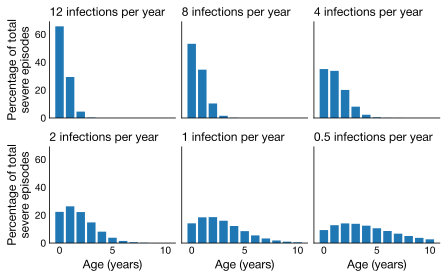

In [7]:
#| label: fig-validate_severe
#| fig-cap: "Model simulations of severe malaria age patterns for a range of transmission intensities using default parameters."

fig, axs = severe_malaria.validate_severe_malaria_risk()

::: {#refs}
:::